# CSE 575 Statistical Machine Learning: runnable companion

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hhsieh14/AI-courses-notes-reader/blob/main/courses/cse-575-statistical-machine-learning/notebooks/cse575_companion.ipynb)

One section per chapter. Each section re-derives a result from the notes numerically, so you can change the numbers and watch what happens. Everything runs on a laptop CPU in under a minute; only NumPy, scikit-learn and Matplotlib are needed.

| § | Chapter | What the code shows |
|---:|---|---|
| 1 | [Linear regression](../docs/01_supervised_learning_and_linear_regression.md) | normal equations and gradient descent reach the same answer |
| 2 | [Bias–variance](../docs/02_generalization_validation_bias_variance.md) | the decomposition, measured over 500 resampled datasets |
| 3 | [Regularization](../docs/03_regularization_and_probabilistic_linear_regression.md) | ridge shrinks, lasso selects |
| 4 | [k-NN](../docs/04_k_nearest_neighbors.md) | k controls the bias–variance trade-off |
| 5 | [Logistic regression](../docs/05_logistic_and_softmax_regression.md) | gradient descent on cross-entropy matches scikit-learn |
| 6 | [Evaluation](../docs/06_classification_evaluation.md) | why accuracy lies on imbalanced data |
| 7 | [Generative classifiers](../docs/07_generative_classification.md) | Gaussian Naive Bayes from counts and means |
| 8 | [SVMs and kernels](../docs/08_support_vector_machines_and_kernels.md) | margins, support vectors, the C trade-off, RBF kernels |
| 9 | [k-means](../docs/09_unsupervised_learning_and_k_means.md) | Lloyd's algorithm never increases the objective |
| 10 | [GMM and EM](../docs/10_gaussian_mixture_models_and_em.md) | EM never decreases the likelihood |
| 11 | [PCA](../docs/11_dimensionality_reduction_and_pca.md) | PCA via SVD, explained variance, reconstruction |
| 12 | [Backpropagation](../docs/12_neural_networks_and_backpropagation.md) | hand-written backprop passes a finite-difference check and learns XOR |

In [1]:
import importlib, subprocess, sys
for pkg, mod in [("numpy", "numpy"), ("scipy", "scipy"), ("matplotlib", "matplotlib"),
                 ("scikit-learn", "sklearn"), ("statsmodels", "statsmodels"), ("PyWavelets", "pywt")]:
    if importlib.util.find_spec(mod) is None:          # e.g. on Colab, PyWavelets may be missing
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.dpi": 80, "figure.figsize": (6.5, 3.6), "axes.grid": True, "grid.alpha": 0.3})

## 1. Linear regression: closed form vs gradient descent

The least-squares solution solves $X^\top X\theta=X^\top y$. Gradient descent on $\tfrac12\lVert X\theta-y\rVert^2$ with step $1/\lambda_{\max}(X^\top X)$ converges to the same point.

closed form     : [2.7575 2.0523]
gradient descent: [2.7575 2.0523]    (true values: [3, 2])


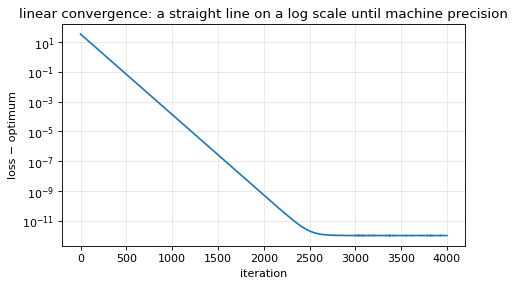

In [2]:
rng = np.random.default_rng(0)
x = rng.uniform(0, 10, 50)
y = 3.0 + 2.0 * x + rng.normal(0, 1, 50)
X = np.column_stack([np.ones_like(x), x])

theta_closed, *_ = np.linalg.lstsq(X, y, rcond=None)
theta = np.zeros(2)
eta = 1.0 / np.linalg.eigvalsh(X.T @ X).max()
history = []
for _ in range(20_000):
    theta -= eta * X.T @ (X @ theta - y)
    history.append(0.5 * np.sum((X @ theta - y) ** 2))

print("closed form     :", theta_closed)
print("gradient descent:", theta, "   (true values: [3, 2])")
gap = np.array(history[:4000]) - min(history) + 1e-12
plt.semilogy(gap); plt.xlabel("iteration"); plt.ylabel("loss − optimum")
plt.title("linear convergence: a straight line on a log scale until machine precision"); plt.show()

## 2. Bias–variance, measured

Fit polynomials of degree 1, 3 and 9 to 500 independent training sets of 20 points from $y=\sin(2\pi x)+\varepsilon$ and look at the spread of predictions at $x_0=0.3$.

degree 1: bias^2 = 0.317   variance = 0.026
degree 3: bias^2 = 0.002   variance = 0.016
degree 9: bias^2 = 0.018   variance = 2.200


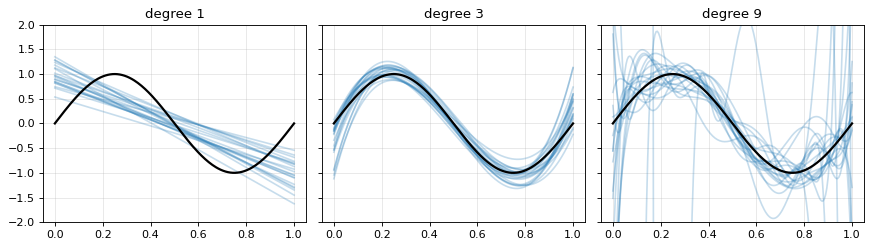

In [3]:
rng = np.random.default_rng(1)
f = lambda x: np.sin(2 * np.pi * x)
x0, grid = 0.3, np.linspace(0, 1, 200)
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2), sharey=True)
for ax, degree in zip(axes, (1, 3, 9)):
    preds = []
    for i in range(500):
        xs = rng.uniform(0, 1, 20); ys = f(xs) + rng.normal(0, 0.3, 20)
        coef = np.polyfit(xs, ys, degree)
        preds.append(np.polyval(coef, x0))
        if i < 20:
            ax.plot(grid, np.polyval(coef, grid), color="tab:blue", alpha=0.25)
    preds = np.array(preds)
    print(f"degree {degree}: bias^2 = {(preds.mean() - f(x0))**2:.3f}   variance = {preds.var():.3f}")
    ax.plot(grid, f(grid), "k", lw=2); ax.set_ylim(-2, 2); ax.set_title(f"degree {degree}")
plt.tight_layout(); plt.show()

## 3. Ridge shrinks, lasso selects

Coefficient paths on the diabetes dataset (10 standardized features). Ridge moves every coefficient smoothly toward zero; lasso sets them to exactly zero one by one.

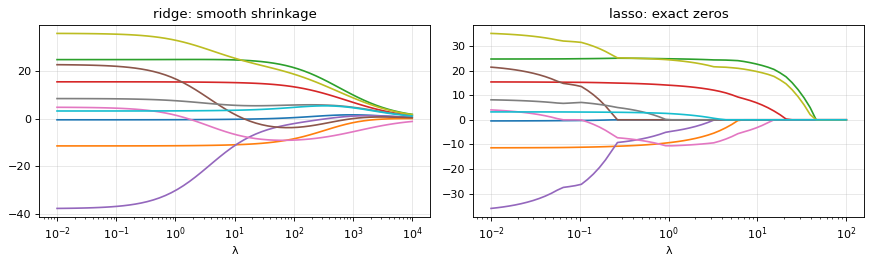

non-zero lasso coefficients as λ grows: λ=0.01: 10, λ=0.07: 9, λ=0.42: 8, λ=2.76: 7, λ=17.96: 3


In [4]:
from sklearn.datasets import load_diabetes
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
Xd, yd = load_diabetes(return_X_y=True)
Xd = StandardScaler().fit_transform(Xd); yd = yd - yd.mean()

alphas_r, alphas_l = np.logspace(-2, 4, 60), np.logspace(-2, 2, 60)
ridge = np.array([Ridge(alpha=a).fit(Xd, yd).coef_ for a in alphas_r])
lasso = np.array([Lasso(alpha=a, max_iter=50_000).fit(Xd, yd).coef_ for a in alphas_l])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.4))
a1.semilogx(alphas_r, ridge); a1.set_title("ridge: smooth shrinkage"); a1.set_xlabel("λ")
a2.semilogx(alphas_l, lasso); a2.set_title("lasso: exact zeros"); a2.set_xlabel("λ")
plt.tight_layout(); plt.show()
print("non-zero lasso coefficients as λ grows:", ", ".join(f"λ={a:.2f}: {int((c != 0).sum())}" for a, c in zip(alphas_l[::12], lasso[::12])))

## 4. k-NN: k is a complexity knob

Small k memorizes the training set (low bias, high variance); large k smooths too much. Five-fold cross-validation picks the middle.

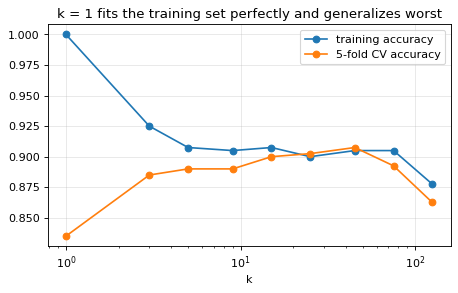

best k by CV: 45  CV accuracy: 0.908


In [5]:
from sklearn.datasets import make_moons
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
Xm, ym = make_moons(400, noise=0.3, random_state=0)
ks = [1, 3, 5, 9, 15, 25, 45, 75, 125]
cv = [cross_val_score(KNeighborsClassifier(k), Xm, ym, cv=5).mean() for k in ks]
train = [KNeighborsClassifier(k).fit(Xm, ym).score(Xm, ym) for k in ks]
plt.semilogx(ks, train, "o-", label="training accuracy"); plt.semilogx(ks, cv, "o-", label="5-fold CV accuracy")
plt.xlabel("k"); plt.legend(); plt.title("k = 1 fits the training set perfectly and generalizes worst"); plt.show()
print("best k by CV:", ks[int(np.argmax(cv))], " CV accuracy:", round(max(cv), 3))

## 5. Logistic regression from scratch

The gradient of the average cross-entropy is $\frac1n X^\top(\sigma(X\theta)-y)$: prediction minus label, the same form as linear regression. Plain gradient descent reaches the same coefficients as scikit-learn's unpenalized solver.

In [6]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
Xc, yc = make_classification(500, n_features=3, n_informative=3, n_redundant=0, random_state=0)
Xb = np.column_stack([np.ones(len(Xc)), Xc])
sigmoid = lambda z: 1 / (1 + np.exp(-z))
theta = np.zeros(Xb.shape[1])
for _ in range(20_000):
    theta -= 0.5 * Xb.T @ (sigmoid(Xb @ theta) - yc) / len(yc)
sk = LogisticRegression(C=1e10, max_iter=10_000).fit(Xc, yc)   # huge C = effectively no penalty
print("gradient descent:", theta)
print("scikit-learn    :", np.r_[sk.intercept_, sk.coef_.ravel()])

gradient descent: [-1.0987  2.7193 -0.9294  1.2997]
scikit-learn    : [-1.0987  2.7191 -0.9294  1.2997]


## 6. Evaluation on imbalanced data

With 2% positives, predicting "negative" for everything scores 98% accuracy and is useless. Precision, recall and PR-AUC expose it; ROC-AUC stays optimistic when negatives are plentiful.

In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, average_precision_score, confusion_matrix
Xi, yi = make_classification(20_000, n_features=10, weights=[0.98], flip_y=0.01, class_sep=0.8, random_state=0)
Xtr, Xte, ytr, yte = Xi[:15_000], Xi[15_000:], yi[:15_000], yi[15_000:]
clf = LogisticRegression(max_iter=1000).fit(Xtr, ytr)
p = clf.predict_proba(Xte)[:, 1]
print(f"positive rate in test: {yte.mean():.3f}")
print(f"always-negative accuracy: {accuracy_score(yte, np.zeros_like(yte)):.3f}")
for t in (0.5, 0.2):
    yhat = (p >= t).astype(int)
    print(f"threshold {t}: accuracy={accuracy_score(yte, yhat):.3f} precision={precision_score(yte, yhat, zero_division=0):.3f} "
          f"recall={recall_score(yte, yhat):.3f}  confusion={confusion_matrix(yte, yhat).ravel()} (tn fp fn tp)")
print(f"ROC-AUC = {roc_auc_score(yte, p):.3f}   PR-AUC (average precision) = {average_precision_score(yte, p):.3f}   (PR-AUC of random guessing = {yte.mean():.3f})")

positive rate in test: 0.028
always-negative accuracy: 0.972
threshold 0.5: accuracy=0.975 precision=1.000 recall=0.101  confusion=[4861    0  125   14] (tn fp fn tp)
threshold 0.2: accuracy=0.976 precision=0.661 recall=0.295  confusion=[4840   21   98   41] (tn fp fn tp)
ROC-AUC = 0.780   PR-AUC (average precision) = 0.401   (PR-AUC of random guessing = 0.028)


## 7. Gaussian Naive Bayes by hand

Fit per-class priors, means and variances; predict with $\arg\max_c\,\log\pi_c+\sum_j\log\mathcal N(x_j;\mu_{cj},\sigma^2_{cj})$.

In [8]:
from sklearn.datasets import load_iris
from sklearn.naive_bayes import GaussianNB
Xr, yr = load_iris(return_X_y=True)
classes = np.unique(yr)
prior = np.array([np.mean(yr == c) for c in classes])
mu = np.array([Xr[yr == c].mean(0) for c in classes])
var = np.array([Xr[yr == c].var(0) for c in classes])
def log_joint(X):
    return np.log(prior) + np.stack([(-0.5 * np.log(2 * np.pi * var[c]) - (X - mu[c])**2 / (2 * var[c])).sum(1) for c in classes], 1)
mine = log_joint(Xr).argmax(1)
sk = GaussianNB(var_smoothing=0).fit(Xr, yr).predict(Xr)
print("training accuracy (by hand):", (mine == yr).mean(), "  agreement with scikit-learn:", (mine == sk).mean())

training accuracy (by hand): 0.96   agreement with scikit-learn: 1.0


## 8. SVMs: margin, support vectors, C and kernels

The hard-margin width is $2/\lVert w\rVert$, and only the points on or inside the margin (the support vectors) determine the solution. Smaller C allows more margin violations; an RBF kernel bends the boundary.

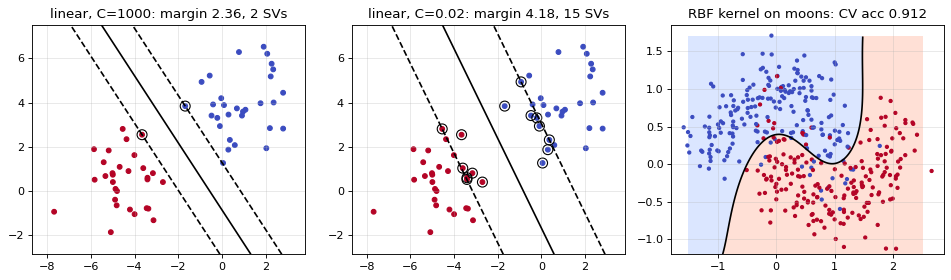

In [9]:
from sklearn.svm import SVC
from sklearn.datasets import make_blobs
Xs, ys = make_blobs(60, centers=2, cluster_std=1.2, random_state=3)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
xx, yy = np.meshgrid(np.linspace(Xs[:, 0].min()-1, Xs[:, 0].max()+1, 300), np.linspace(Xs[:, 1].min()-1, Xs[:, 1].max()+1, 300))
for ax, C in zip(axes[:2], (1000, 0.02)):
    m = SVC(kernel="linear", C=C).fit(Xs, ys)
    Z = m.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contour(xx, yy, Z, levels=[-1, 0, 1], linestyles=["--", "-", "--"], colors="k")
    ax.scatter(*Xs.T, c=ys, cmap="coolwarm", s=18)
    ax.scatter(*m.support_vectors_.T, s=80, facecolors="none", edgecolors="k")
    ax.set_title(f"linear, C={C}: margin {2/np.linalg.norm(m.coef_):.2f}, {len(m.support_)} SVs")
m = SVC(kernel="rbf", C=1, gamma=1).fit(Xm, ym)
g = np.meshgrid(np.linspace(-1.5, 2.5, 300), np.linspace(-1.2, 1.7, 300))
Z = m.decision_function(np.c_[g[0].ravel(), g[1].ravel()]).reshape(g[0].shape)
axes[2].contourf(*g, Z, levels=[-50, 0, 50], colors=["#dbe6ff", "#ffe0d6"]); axes[2].contour(*g, Z, levels=[0], colors="k"); axes[2].scatter(*Xm.T, c=ym, cmap="coolwarm", s=8)
axes[2].set_title(f"RBF kernel on moons: CV acc {cross_val_score(SVC(kernel='rbf', gamma=1), Xm, ym, cv=5).mean():.3f}")
plt.tight_layout(); plt.show()

## 9. k-means: Lloyd's algorithm

Each assignment step and each mean-update step can only lower the within-cluster sum of squares $J$, so $J$ is monotone and the algorithm stops, at a local optimum.

start 0: final J = 1127.4
start 1: final J = 5133.5
start 2: final J = 1127.4
start 3: final J = 14149.4
start 4: final J = 5133.5
J never increased in any run, but different starts stop in different local optima: run several and keep the best (or use k-means++).


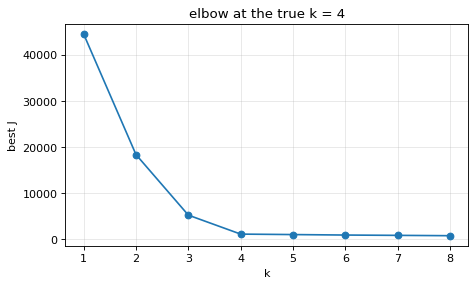

In [10]:
def kmeans(X, k, seed, iters=50):
    r = np.random.default_rng(seed); C = X[r.choice(len(X), k, replace=False)]; J = []
    for _ in range(iters):
        d = ((X[:, None, :] - C[None]) ** 2).sum(-1); z = d.argmin(1)
        J.append(d[np.arange(len(X)), z].sum())
        C = np.array([X[z == j].mean(0) if np.any(z == j) else C[j] for j in range(k)])
    return C, z, np.array(J)
Xk, _ = make_blobs(600, centers=4, cluster_std=1.0, random_state=7)
runs = [kmeans(Xk, 4, s) for s in range(5)]
for s, (_, _, J) in enumerate(runs):
    assert np.all(np.diff(J) <= 1e-9), "J increased!"
    print(f"start {s}: final J = {J[-1]:.1f}")
print("J never increased in any run, but different starts stop in different local optima: run several and keep the best (or use k-means++).")
elbow = [min(kmeans(Xk, k, s)[2][-1] for s in range(3)) for k in range(1, 9)]
plt.plot(range(1, 9), elbow, "o-"); plt.xlabel("k"); plt.ylabel("best J"); plt.title("elbow at the true k = 4"); plt.show()

## 10. Gaussian mixture EM

E-step: responsibilities. M-step: weighted means, covariances and mixing weights. The log-likelihood never decreases, which is the ELBO argument from the chapter, checked numerically.

monotone: True   final log-likelihood (by hand): -1705.25
scikit-learn log-likelihood: -1705.51  (same optimum; scikit-learn stops at a looser tolerance)


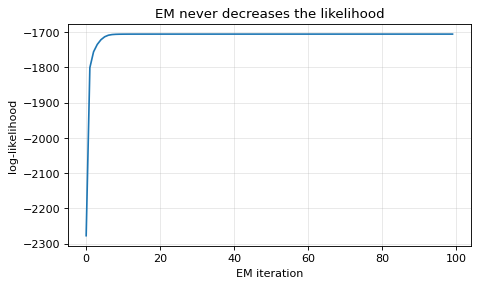

In [11]:
from scipy.stats import multivariate_normal as mvn
from sklearn.mixture import GaussianMixture
Xg, _ = make_blobs(500, centers=[[0, 0], [3, 3], [0, 4]], cluster_std=[0.8, 1.2, 0.6], random_state=0)
K, n = 3, len(Xg); r = np.random.default_rng(0)
mu = Xg[r.choice(n, K, replace=False)]; Sig = np.array([np.eye(2)] * K); pi = np.ones(K) / K; ll = []
for _ in range(100):
    dens = np.column_stack([pi[k] * mvn.pdf(Xg, mu[k], Sig[k]) for k in range(K)])
    ll.append(np.log(dens.sum(1)).sum())
    R = dens / dens.sum(1, keepdims=True)                      # E-step
    Nk = R.sum(0); pi = Nk / n; mu = (R.T @ Xg) / Nk[:, None]  # M-step
    Sig = np.array([((R[:, k, None] * (Xg - mu[k])).T @ (Xg - mu[k])) / Nk[k] + 1e-6 * np.eye(2) for k in range(K)])
print("monotone:", bool(np.all(np.diff(ll) >= -1e-8)), "  final log-likelihood (by hand):", round(ll[-1], 2))
sk = GaussianMixture(3, random_state=0).fit(Xg)
print("scikit-learn log-likelihood:", round(sk.score(Xg) * n, 2), " (same optimum; scikit-learn stops at a looser tolerance)")
plt.plot(ll); plt.xlabel("EM iteration"); plt.ylabel("log-likelihood"); plt.title("EM never decreases the likelihood"); plt.show()

## 11. PCA via the SVD

On centered data $X=U\Sigma V^\top$: the rows of $V^\top$ are the principal directions and $\sigma_m^2/(n-1)$ their variances. Reconstruction from the top $k$ components is the best rank-$k$ approximation.

explained variance of first 5 PCs (SVD): [0.1489 0.1362 0.1179 0.0841 0.0578]
scikit-learn agrees: True
21 of 64 components keep 90% of the variance


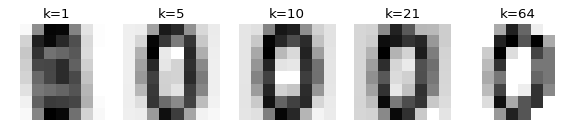

In [12]:
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
Xdg = load_digits().data; Xc = Xdg - Xdg.mean(0)
U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
evr = S**2 / (S**2).sum()
print("explained variance of first 5 PCs (SVD):", evr[:5])
print("scikit-learn agrees:", np.allclose(evr[:5], PCA(5).fit(Xdg).explained_variance_ratio_))
k90 = int(np.searchsorted(np.cumsum(evr), 0.9)) + 1
print(f"{k90} of 64 components keep 90% of the variance")
fig, axes = plt.subplots(1, 5, figsize=(9, 2))
for ax, k in zip(axes, (1, 5, 10, k90, 64)):
    rec = (U[:, :k] * S[:k]) @ Vt[:k] + Xdg.mean(0)
    ax.imshow(rec[0].reshape(8, 8), cmap="gray_r"); ax.set_title(f"k={k}"); ax.axis("off")
plt.show()

## 12. Backpropagation, checked and trained

The backward pass from the chapter (sigmoid hidden layer, sigmoid output, summed binary cross-entropy) matches central finite differences to about $10^{-9}$, then gradient descent learns XOR, which no linear model can.

largest |backprop − finite difference| = 3.3e-10


predictions after training: [0.    0.999 0.999 0.002]


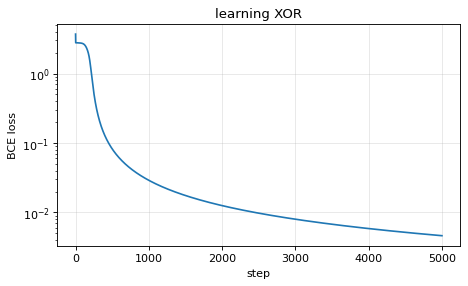

In [13]:
sig = lambda z: 1 / (1 + np.exp(-z))
def forward_backward(X, y, W1, b2, W2, b3):
    a2 = sig(X @ W1 + b2); a3 = sig(a2 @ W2 + b3)
    loss = -np.sum(y * np.log(a3) + (1 - y) * np.log(1 - a3))
    d3 = a3 - y; d2 = (d3 @ W2.T) * a2 * (1 - a2)
    return loss, [X.T @ d2, d2.sum(0), a2.T @ d3, d3.sum(0)]

Xx = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], float); yx = np.array([[0], [1], [1], [0]], float)
r = np.random.default_rng(0)
params = [r.normal(0, 1, (2, 4)), np.zeros(4), r.normal(0, 1, (4, 1)), np.zeros(1)]
_, grads = forward_backward(Xx, yx, *params)
worst = 0
for P, G in zip(params, grads):
    for idx in np.ndindex(P.shape):
        old = P[idx]; P[idx] = old + 1e-6; lp, _ = forward_backward(Xx, yx, *params)
        P[idx] = old - 1e-6; lm, _ = forward_backward(Xx, yx, *params); P[idx] = old
        worst = max(worst, abs((lp - lm) / 2e-6 - G[idx]))
print(f"largest |backprop − finite difference| = {worst:.1e}")

losses = []
for _ in range(5000):
    loss, grads = forward_backward(Xx, yx, *params); losses.append(loss)
    for P, G in zip(params, grads): P -= 0.5 * G
print("predictions after training:", sig(sig(Xx @ params[0] + params[1]) @ params[2] + params[3]).ravel().round(3))
plt.semilogy(losses); plt.xlabel("step"); plt.ylabel("BCE loss"); plt.title("learning XOR"); plt.show()